<a href="https://colab.research.google.com/github/Striukova2910/llm-hallucination-detector/blob/main/notebooks/04_nli_deberta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **NLI-based Hallucination Detection with DeBERTa

This experiment formulates hallucination detection as a Natural Language
Inference (NLI) task.

- Premise: reference evidence
- Hypothesis: answer to be checked
- Entailment: the answer is supported by the evidence
- Neutral or contradiction: the answer is unsupported or contradicted

The pretrained NLI model is first evaluated without additional fine-tuning.
The existing counterfactual dataset is used as a diagnostic stress test.**

In [1]:
import warnings
warnings.filterwarnings("ignore")

from huggingface_hub.utils import logging as hf_logging
from transformers.utils import logging as transformers_logging

hf_logging.set_verbosity_error()
transformers_logging.set_verbosity_error()
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)
from google.colab import files
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import shutil
import zipfile
from pathlib import Path


# Display settings
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

warnings.filterwarnings("ignore")

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
uploaded = files.upload()

Saving counterfactual_test (1).csv to counterfactual_test (1).csv


In [ ]:
file_name = next(iter(uploaded))

counterfactual_df = pd.read_csv(file_name)

print("Loaded file:", file_name)
print("Shape:", counterfactual_df.shape)
print("Columns:", counterfactual_df.columns.tolist())

counterfactual_df.head()

Loaded file: counterfactual_test (1).csv
Shape: (40, 8)
Columns: ['test_id', 'group_id', 'question', 'answer_style', 'answer', 'reference_evidence', 'expected_label', 'manipulation']


,test_id,group_id,question,answer_style,answer,reference_evidence,expected_label,manipulation
0,1,hamlet,Who wrote Hamlet?,short,William Shakespeare wrote Hamlet.,Hamlet was written by William Shakespeare.,0,none
1,2,hamlet,Who wrote Hamlet?,short,Edgar Allan Poe wrote Hamlet.,Hamlet was written by William Shakespeare.,1,author_substitution
2,3,hamlet,Who wrote Hamlet?,long,William Shakespeare wrote Hamlet. It is one of his most famous tragedies and was likely written around 1600.,Hamlet was written by William Shakespeare.,0,none
3,4,hamlet,Who wrote Hamlet?,long,Edgar Allan Poe wrote Hamlet. It is one of his most famous tragedies and was likely written around 1600.,Hamlet was written by William Shakespeare.,1,author_substitution
4,5,france_capital,What is the capital of France?,short,Paris is the capital of France.,Paris is the capital and most populous city of France.,0,none


In [ ]:
# upload DeBERTa
MODEL_NAME = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME
)

model = model.to(DEVICE)
model.eval()

print("Model:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)
print("Label mapping:", model.config.id2label)

In [ ]:
# nli prediction function
label_to_id = {
    label.lower(): label_id
    for label_id, label in model.config.id2label.items()
}

ENTAILMENT_ID = label_to_id["entailment"]
NEUTRAL_ID = label_to_id["neutral"]
CONTRADICTION_ID = label_to_id["contradiction"]


def predict_nli(reference_evidence, answer):
    encoded = tokenizer(
        reference_evidence,
        answer,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    )

    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    with torch.inference_mode():
        logits = model(**encoded).logits
        probabilities = torch.softmax(logits, dim=-1)[0].cpu().numpy()

    entailment_probability = probabilities[ENTAILMENT_ID]
    neutral_probability = probabilities[NEUTRAL_ID]
    contradiction_probability = probabilities[CONTRADICTION_ID]

    # Unsupported or contradictory answers are treated as hallucinations.
    hallucination_probability = (
        neutral_probability + contradiction_probability
    )

    predicted_label = int(hallucination_probability >= 0.5)

    return {
        "entailment_probability": float(entailment_probability),
        "neutral_probability": float(neutral_probability),
        "contradiction_probability": float(contradiction_probability),
        "hallucination_probability": float(hallucination_probability),
        "predicted_label": predicted_label,
    }

In [ ]:
# sanity check
reference = "Hamlet was written by William Shakespeare."

correct_answer = predict_nli(
    reference,
    "William Shakespeare wrote Hamlet.",
)

incorrect_answer = predict_nli(
    reference,
    "Edgar Allan Poe wrote Hamlet.",
)

print("Correct answer:")
for name, value in correct_answer.items():
    print(f"{name}: {value:.4f}" if isinstance(value, float) else f"{name}: {value}")

print("\nIncorrect answer:")
for name, value in incorrect_answer.items():
    print(f"{name}: {value:.4f}" if isinstance(value, float) else f"{name}: {value}")

Correct answer:
entailment_probability: 0.9985
neutral_probability: 0.0010
contradiction_probability: 0.0003
hallucination_probability: 0.0013
predicted_label: 0

Incorrect answer:
entailment_probability: 0.0002
neutral_probability: 0.0018
contradiction_probability: 0.9980
hallucination_probability: 1.0000
predicted_label: 1


In [ ]:
# columns
required_columns = {
    "reference_evidence",
    "answer",
    "expected_label",
    "answer_style",
}

missing_columns = required_columns - set(counterfactual_df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

print("Rows:", len(counterfactual_df))
print("Required columns found:", sorted(required_columns))

counterfactual_df[
    [
        "reference_evidence",
        "answer",
        "expected_label",
        "answer_style",
    ]
].head()

Rows: 40
Required columns found: ['answer', 'answer_style', 'expected_label', 'reference_evidence']


,reference_evidence,answer,expected_label,answer_style
0,Hamlet was written by William Shakespeare.,William Shakespeare wrote Hamlet.,0,short
1,Hamlet was written by William Shakespeare.,Edgar Allan Poe wrote Hamlet.,1,short
2,Hamlet was written by William Shakespeare.,William Shakespeare wrote Hamlet. It is one of his most famous tragedies and was likely written around 1600.,0,long
3,Hamlet was written by William Shakespeare.,Edgar Allan Poe wrote Hamlet. It is one of his most famous tragedies and was likely written around 1600.,1,long
4,Paris is the capital and most populous city of France.,Paris is the capital of France.,0,short


In [ ]:
# DeBERTa predictions
prediction_records = []

for _, row in counterfactual_df.iterrows():
    prediction = predict_nli(
        reference_evidence=row["reference_evidence"],
        answer=row["answer"],
    )
    prediction_records.append(prediction)

prediction_df = pd.DataFrame(prediction_records)

deberta_results = pd.concat(
    [
        counterfactual_df.reset_index(drop=True),
        prediction_df,
    ],
    axis=1,
)

print("Predictions completed:", len(deberta_results))

deberta_results[
    [
        "expected_label",
        "predicted_label",
        "hallucination_probability",
        "answer_style",
    ]
].head(10)

Predictions completed: 40


,expected_label,predicted_label,hallucination_probability,answer_style
0,0,0,0.001258,short
1,1,1,1.000000,short
2,0,1,0.981445,long
3,1,1,0.999512,long
4,0,0,0.002155,short
5,1,1,1.000000,short
6,0,1,0.994629,long
7,1,1,1.000000,long
8,0,0,0.002834,short
9,1,1,0.999512,short


In [ ]:
# metrics
y_true = deberta_results["expected_label"].astype(int)
y_pred = deberta_results["predicted_label"].astype(int)
y_probability = deberta_results["hallucination_probability"]

print("DeBERTa NLI — OOD counterfactual stress test\n")

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_probability):.4f}")
print(f"PR-AUC:    {average_precision_score(y_true, y_probability):.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Non-Hallucination",
            "Hallucination",
        ],
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

deberta_results["is_correct"] = (
    deberta_results["expected_label"]
    == deberta_results["predicted_label"]
)

print("\nAccuracy by answer style:")
print(
    deberta_results
    .groupby("answer_style")["is_correct"]
    .mean()
)

print("\nPredicted hallucination rate by answer style:")
print(
    deberta_results
    .groupby("answer_style")["predicted_label"]
    .mean()
)

DeBERTa NLI — OOD counterfactual stress test

Accuracy:  0.7500
Precision: 0.6667
Recall:    1.0000
F1-score:  0.8000
ROC-AUC:   0.9850
PR-AUC:    0.9808

Classification report:
                   precision    recall  f1-score   support

Non-Hallucination     1.0000    0.5000    0.6667        20
    Hallucination     0.6667    1.0000    0.8000        20

         accuracy                         0.7500        40
        macro avg     0.8333    0.7500    0.7333        40
     weighted avg     0.8333    0.7500    0.7333        40

Confusion matrix:
[[10 10]
 [ 0 20]]

Accuracy by answer style:
answer_style
long     0.55
short    0.95
Name: is_correct, dtype: float64

Predicted hallucination rate by answer style:
answer_style
long     0.95
short    0.55
Name: predicted_label, dtype: float64


In [ ]:
# errors analysis
pd.set_option("display.max_colwidth", 200)

error_rows = deberta_results[
    deberta_results["expected_label"]
    != deberta_results["predicted_label"]
].copy()

display_columns = [
    column
    for column in [
        "question",
        "reference_evidence",
        "answer",
        "answer_style",
        "expected_label",
        "predicted_label",
        "entailment_probability",
        "neutral_probability",
        "contradiction_probability",
        "hallucination_probability",
    ]
    if column in error_rows.columns
]

print("Number of errors:", len(error_rows))

display(
    error_rows[display_columns]
    .sort_values(
        "hallucination_probability",
        ascending=False,
    )
)

Number of errors: 10


,question,reference_evidence,answer,answer_style,expected_label,predicted_label,entailment_probability,neutral_probability,contradiction_probability,hallucination_probability
34,What is the capital of Australia?,Canberra is the capital city of Australia.,Canberra is the capital of Australia and was selected as a compromise between the larger cities of Sydney and Melbourne.,long,0,1,0.001030,0.998535,0.000320,0.999023
38,How many chromosomes are normally present in a human somatic cell?,Human somatic cells normally contain 46 chromosomes arranged in 23 pairs.,"A human somatic cell normally contains 46 chromosomes, organized into 23 pairs inherited from the person's biological parents.",long,0,1,0.004578,0.994629,0.000994,0.995605
18,What is the largest planet in the Solar System?,Jupiter is the largest planet in the Solar System.,Jupiter is the largest planet in the Solar System and is a gas giant with a mass greater than all the other planets combined.,long,0,1,0.005527,0.993652,0.001044,0.994629
6,What is the capital of France?,Paris is the capital and most populous city of France.,Paris is the capital of France and serves as the country's major political and cultural center.,long,0,1,0.005352,0.994141,0.000437,0.994629
26,Who painted the Mona Lisa?,The Mona Lisa was painted by Leonardo da Vinci.,"Leonardo da Vinci painted the Mona Lisa, which is now displayed at the Louvre Museum in Paris.",long,0,1,0.008949,0.990723,0.000492,0.991211
2,Who wrote Hamlet?,Hamlet was written by William Shakespeare.,William Shakespeare wrote Hamlet. It is one of his most famous tragedies and was likely written around 1600.,long,0,1,0.018234,0.980957,0.000659,0.981445
22,Who wrote the novel 1984?,The dystopian novel 1984 was written by George Orwell.,"George Orwell wrote the novel 1984, a dystopian work about totalitarian surveillance and political control.",long,0,1,0.031143,0.968262,0.000638,0.968750
10,What is the chemical formula for water?,Water is a chemical compound with the formula H2O.,"The chemical formula for water is H2O, indicating that each molecule contains two hydrogen atoms and one oxygen atom.",long,0,1,0.036682,0.953613,0.009605,0.963379
30,At what temperature does water boil at standard sea-level pressure?,"At standard atmospheric pressure, water boils at 100 degrees Celsius.","Water boils at 100 degrees Celsius at standard sea-level pressure, although the boiling point changes when atmospheric pressure changes.",long,0,1,0.041412,0.955078,0.003687,0.958984
28,At what temperature does water boil at standard sea-level pressure?,"At standard atmospheric pressure, water boils at 100 degrees Celsius.",Water boils at 100 degrees Celsius at sea level.,short,0,1,0.104797,0.729492,0.165771,0.895508


In [ ]:
# FP analysis
false_positives = deberta_results[
    (deberta_results["expected_label"] == 0)
    & (deberta_results["predicted_label"] == 1)
]

print("False positives:", len(false_positives))

print("\nMean probabilities for false positives:")
print(
    false_positives[
        [
            "entailment_probability",
            "neutral_probability",
            "contradiction_probability",
            "hallucination_probability",
        ]
    ].mean().round(4)
)

print("\nFalse positives by answer style:")
print(false_positives["answer_style"].value_counts())

False positives: 10

Mean probabilities for false positives:
entailment_probability       0.0258
neutral_probability          0.9559
contradiction_probability    0.0184
hallucination_probability    0.9743
dtype: float64

False positives by answer style:
answer_style
long     9
short    1
Name: count, dtype: int64


Instead of forcing every prediction into a binary hallucination label, the
model output is analyzed using its three original NLI classes:

- **Supported** — the answer is entailed by the reference evidence.
- **Unverifiable** — the available evidence is insufficient to confirm or
  contradict the answer.
- **Contradicted** — the answer directly contradicts the reference evidence.

The class with the highest predicted probability is selected as the final
NLI status.

In [ ]:
# three-way NLI status
probability_columns = [
    "entailment_probability",
    "neutral_probability",
    "contradiction_probability",
]

nli_status_names = np.array([
    "supported",
    "unverifiable",
    "contradicted",
])

deberta_results["nli_status"] = nli_status_names[
    deberta_results[probability_columns]
    .to_numpy()
    .argmax(axis=1)
]

print("NLI status counts:")
print(deberta_results["nli_status"].value_counts())

print("\nNLI status by expected label:")
print(
    pd.crosstab(
        deberta_results["expected_label"],
        deberta_results["nli_status"],
        margins=True,
    )
)

print("\nNLI status by answer style:")
print(
    pd.crosstab(
        deberta_results["answer_style"],
        deberta_results["nli_status"],
        margins=True,
    )
)

NLI status counts:
nli_status
contradicted    19
unverifiable    11
supported       10
Name: count, dtype: int64

NLI status by expected label:
nli_status      contradicted  supported  unverifiable  All
expected_label                                            
0                          0         10            10   20
1                         19          0             1   20
All                       19         10            11   40

NLI status by answer style:
nli_status    contradicted  supported  unverifiable  All
answer_style                                            
long                    10          1             9   20
short                    9          9             2   20
All                     19         10            11   40


DeBERTa classified 19 examples as contradicted, 11 as unverifiable, and
10 as supported.

Among the 20 correct answers, none was classified as contradicted:
10 were supported and 10 were unverifiable. Among the 20 hallucinated
answers, 19 were classified as contradicted and one as unverifiable.

Most unverifiable correct answers were long responses containing additional
details that were not fully covered by the reference evidence. This shows
why neutral and contradiction should not always be combined into a single
hallucination class.

In [ ]:
# contradiction-focused evaluation
deberta_results["contradiction_prediction"] = (
    deberta_results["nli_status"] == "contradicted"
).astype(int)

y_contradiction_pred = deberta_results["contradiction_prediction"]

print("Contradiction-focused evaluation\n")

print(
    f"Accuracy:  "
    f"{accuracy_score(y_true, y_contradiction_pred):.4f}"
)
print(
    f"Precision: "
    f"{precision_score(y_true, y_contradiction_pred, zero_division=0):.4f}"
)
print(
    f"Recall:    "
    f"{recall_score(y_true, y_contradiction_pred, zero_division=0):.4f}"
)
print(
    f"F1-score:  "
    f"{f1_score(y_true, y_contradiction_pred, zero_division=0):.4f}"
)

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_contradiction_pred,
        target_names=[
            "Non-Hallucination",
            "Hallucination",
        ],
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_true, y_contradiction_pred))

Contradiction-focused evaluation

Accuracy:  0.9750
Precision: 1.0000
Recall:    0.9500
F1-score:  0.9744

Classification report:
                   precision    recall  f1-score   support

Non-Hallucination     0.9524    1.0000    0.9756        20
    Hallucination     1.0000    0.9500    0.9744        20

         accuracy                         0.9750        40
        macro avg     0.9762    0.9750    0.9750        40
     weighted avg     0.9762    0.9750    0.9750        40

Confusion matrix:
[[20  0]
 [ 1 19]]


This evaluation focuses specifically on direct factual contradictions.
Only the **contradicted** NLI status is treated as hallucination.
Supported and unverifiable answers are not classified as direct
contradictions.

This analysis is reported alongside the stricter groundedness evaluation
and does not replace it.

The contradiction-focused approach achieved 97.5% accuracy, 100% precision,
95% recall, and a 97.4% F1-score.

The model correctly identified 19 of the 20 hallucinated answers and did not
incorrectly classify any correct answer as a contradiction. The only missed
hallucination involved a numerical inconsistency: the evidence stated
100 degrees Celsius, while the answer stated 80 degrees Celsius.

These findings indicate that DeBERTa is highly effective at detecting direct
factual contradictions in this diagnostic dataset, although additional
testing is required for numerical reasoning, unsupported claims, and broader
subject domains.

In [ ]:
# missed hallucination analysis
missed_hallucinations = deberta_results[
    (deberta_results["expected_label"] == 1)
    & (deberta_results["contradiction_prediction"] == 0)
]

display_columns = [
    column
    for column in [
        "question",
        "reference_evidence",
        "answer",
        "answer_style",
        "nli_status",
        "entailment_probability",
        "neutral_probability",
        "contradiction_probability",
    ]
    if column in missed_hallucinations.columns
]

print(
    "Missed hallucinations:",
    len(missed_hallucinations),
)

display(missed_hallucinations[display_columns])

Missed hallucinations: 1


,question,reference_evidence,answer,answer_style,nli_status,entailment_probability,neutral_probability,contradiction_probability
29,At what temperature does water boil at standard sea-level pressure?,"At standard atmospheric pressure, water boils at 100 degrees Celsius.",Water boils at 80 degrees Celsius at sea level.,short,unverifiable,0.002838,0.975586,0.021469


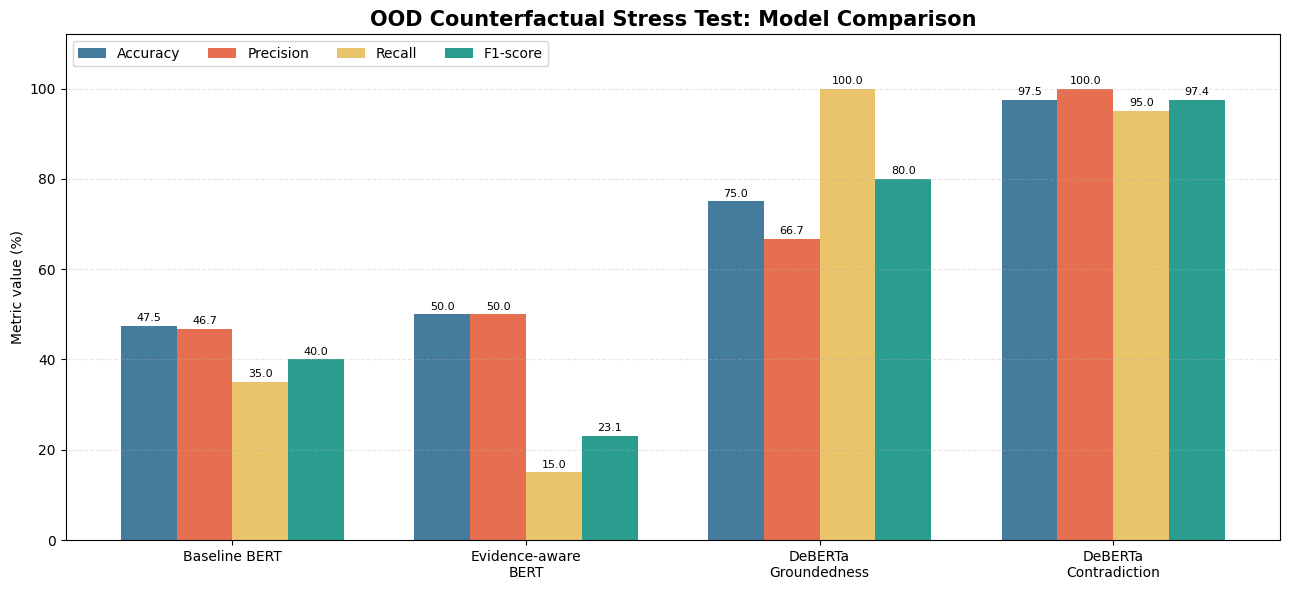

In [ ]:
# plot
approaches = [
    "Baseline BERT",
    "Evidence-aware\nBERT",
    "DeBERTa\nGroundedness",
    "DeBERTa\nContradiction",
]

comparison_metrics = {
    "Accuracy": [47.5, 50.0, 75.0, 97.5],
    "Precision": [46.7, 50.0, 66.7, 100.0],
    "Recall": [35.0, 15.0, 100.0, 95.0],
    "F1-score": [40.0, 23.1, 80.0, 97.4],
}

colors = [
    "#457B9D",
    "#E76F51",
    "#E9C46A",
    "#2A9D8F",
]

x = np.arange(len(approaches))
width = 0.19

fig, ax = plt.subplots(figsize=(13, 6))

for metric_index, (metric_name, values) in enumerate(
    comparison_metrics.items()
):
    offset = (
        metric_index - (len(comparison_metrics) - 1) / 2
    ) * width

    bars = ax.bar(
        x + offset,
        values,
        width,
        label=metric_name,
        color=colors[metric_index],
    )

    ax.bar_label(
        bars,
        fmt="%.1f",
        padding=2,
        fontsize=8,
    )

ax.set_title(
    "OOD Counterfactual Stress Test: Model Comparison",
    fontsize=15,
    fontweight="bold",
)

ax.set_ylabel("Metric value (%)")
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylim(0, 112)
ax.legend(ncol=4, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/ood_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()



The baseline BERT and evidence-aware BERT models achieved 47.5% and 50.0% accuracy on the small out-of-distribution counterfactual stress test.

The pretrained NLI-based DeBERTa model performed substantially better. Under the strict groundedness interpretation, where both neutral and contradictory answers are flagged, it achieved 75.0% accuracy and 100.0% hallucination recall. Most false positives were long, factually correct answers containing details not covered by the provided evidence.

Under the contradiction-focused interpretation, DeBERTa achieved 97.5% accuracy, 100.0% precision, 95.0% recall, and a 97.4% F1-score. It correctly identified 19 of 20 hallucinations without falsely marking any correct answer as contradictory.

The only missed hallucination involved a numerical contradiction: the evidence stated 100 degrees Celsius, while the answer stated 80 degrees Celsius. The model classified this example as unverifiable rather than contradicted, demonstrating a limitation in numerical reasoning.

Based on these results, the pretrained NLI-based DeBERTa model was selected as the final inference approach for the project. Unlike the fine-tuned BERT classifiers, it directly evaluates whether an answer is supported by, contradicts, or is neutral to the provided evidence. This makes the model better aligned with the actual goal of factual hallucination detection.

The main remaining limitation is that the external stress test contains only 40 examples, so these results should be treated as diagnostic rather than definitive. A larger and more diverse evaluation set would be the next step for validating the model’s robustness.

In [ ]:
# save and download all DeBERTa experiment outputs
results_path = Path("/content/deberta_ood_results.csv")
metrics_path = Path("/content/model_comparison_metrics.csv")
figure_path = Path("/content/ood_model_comparison.png")
archive_path = Path("/content/deberta_experiment_outputs.zip")

# save detailed predictions
deberta_results.to_csv(
    results_path,
    index=False,
)

# save comparison metrics
comparison_df = pd.DataFrame(
    comparison_metrics,
    index=approaches,
).reset_index(names="approach")

comparison_df.to_csv(
    metrics_path,
    index=False,
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

# create a ZIP archive
with zipfile.ZipFile(
    archive_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    archive.write(results_path, arcname=results_path.name)
    archive.write(metrics_path, arcname=metrics_path.name)
    archive.write(figure_path, arcname=figure_path.name)

print("Files added to archive:")

for path in [results_path, metrics_path, figure_path]:
    print(f"{path.name}: {path.exists()}")

files.download(str(archive_path))

Files added to archive:
deberta_ood_results.csv: True
model_comparison_metrics.csv: True
ood_model_comparison.png: True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>